1. Selecione uma serie temporal de sua preferência com dados faltantes ou selecionar uma completa. Elimine algumas observações e estime-as utilizando diferentes técnicas. Em seguida, compare os dados estimados com aqueles eliminados.

In [1]:
# Python 3.11.9
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Definindo função de plotagem de série temporal:
def plotar(serie, titulo, y='EUR'):
    plt.figure(figsize=(10, 4))
    plt.plot(serie)
    plt.title(titulo)
    plt.xlabel('Tempo')
    plt.ylabel(y)
    plt.show()

In [3]:
# Lendo o dataframe escolhido baixado no Kaggle em https://www.kaggle.com/datasets/ruchi798/currency-exchange-rates
df = pd.read_csv('exchange_rates.csv')

# Conversão da coluna de data e definição como índice
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

# Selecionando apenas USD para criar uma série temporal (ts):
ts = df[df['currency'] == 'USD']
ts = ts.drop(['Unnamed: 0', 'Country/Currency', 'currency'], axis=1)
ts

C:\Users\Beatriz\AppData\Local\Temp\ipykernel_20176\2230342053.py:5: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(df['date'])


,value
date,
2021-12-17,1.132548
2021-12-18,1.123810
2021-12-19,1.123810
2021-12-20,1.124405
2021-12-21,1.128382
...,...
2025-10-23,1.160827
2025-10-24,1.161713
2025-10-25,1.162650


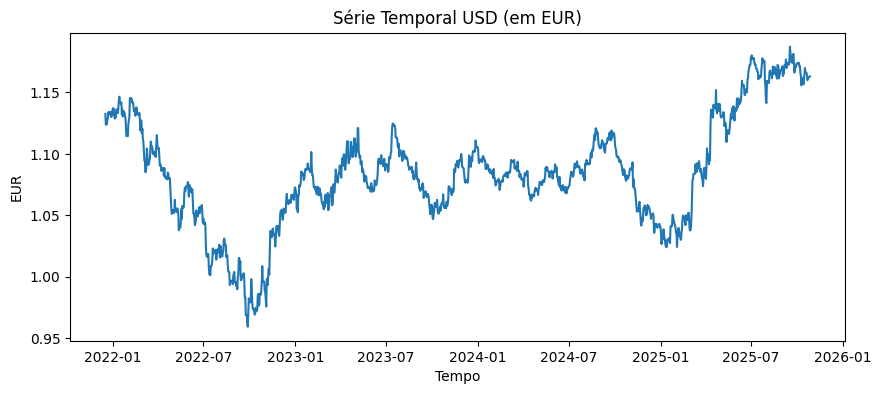

In [4]:
plotar(ts, 'Série Temporal USD (em EUR)')

In [5]:
# Remoção: Salvando cópia da série temporal para remover intervalos:
ts_missing_block = ts.copy()

# Definindo intervalos:
data_inicio_remocao = ['2022-03-01','2023-01-01', '2024-05-01', '2024-12-01']
data_fim_remocao = ['2022-05-31', '2023-03-31', '2024-06-30', '2025-02-28']

# Preenchendo intervalos com Nan:
for inicio, fim in zip(data_inicio_remocao, data_fim_remocao):
    # Removendo (substituindo por NaN) o bloco de dados
    ts_missing_block.loc[inicio:fim] = np.nan

print(f"Número de observações removidas em bloco: {ts_missing_block.isna().sum()}")

Número de observações removidas em bloco: value    332
dtype: int64


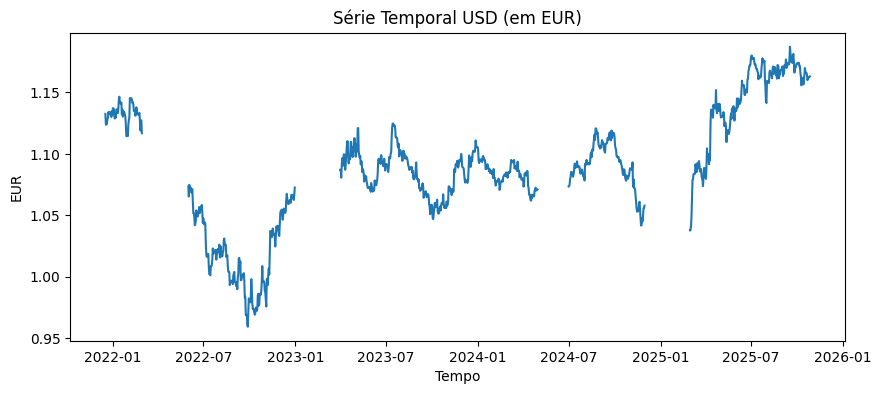

In [6]:
plotar(ts_missing_block,'Série Temporal USD (em EUR)')

In [7]:
# Seleciona apenas os index (datas) onde há NaN na série modificada (ts_missing_multi)
indices_removidos = ts_missing_block[ts_missing_block.isna()].index

# E usa os index para pegar os dados verdadeiros correspondentes para comparação
dados_eliminados_verdadeiros = ts.loc[indices_removidos]

dados_eliminados_verdadeiros

,value
date,
2021-12-17,1.132548
2021-12-18,1.123810
2021-12-19,1.123810
2021-12-20,1.124405
2021-12-21,1.128382
...,...
2025-10-23,1.160827
2025-10-24,1.161713
2025-10-25,1.162650


Estimando com diferentes técnicas:

In [8]:
# TÉCNICA 1: Imputação Simples (Baseline)
# Usando a média de toda a série
ts_media = ts_missing_block.fillna(ts_missing_block.mean())

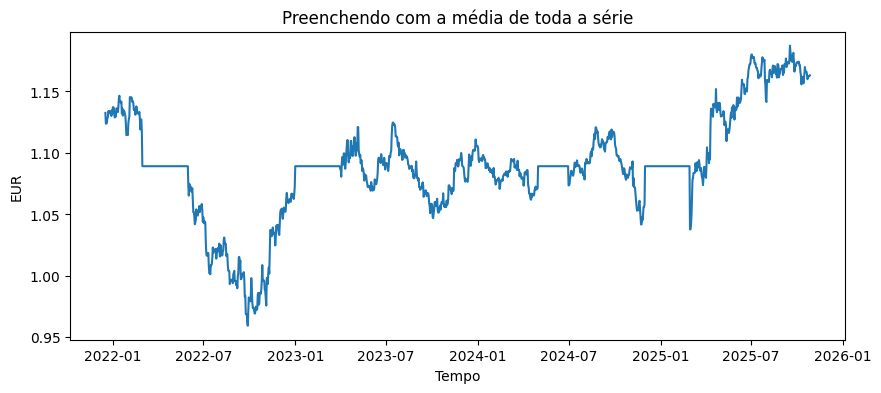

In [9]:
plotar(ts_media, 'Preenchendo com a média de toda a série')

In [10]:
# Usando a Última Observação Válida (LOCF - Last Observation Carried Forward)
ts_locf = ts_missing_block.fillna(method='ffill') 

C:\Users\Beatriz\AppData\Local\Temp\ipykernel_20176\2637836688.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ts_locf = ts_missing_block.fillna(method='ffill')


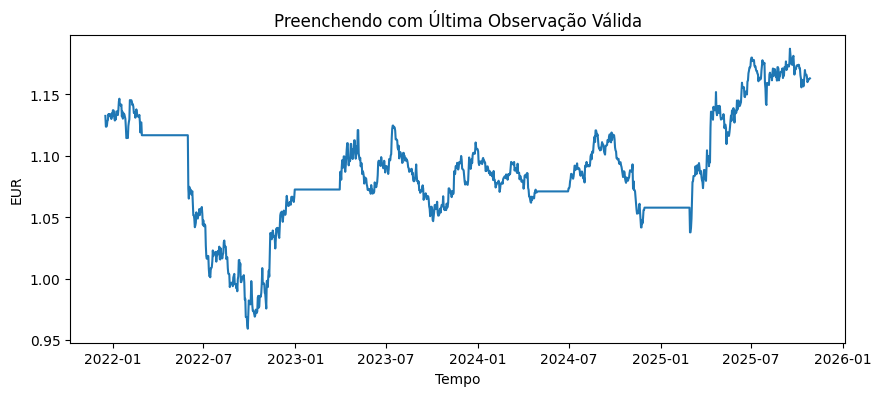

In [11]:
plotar(ts_locf, 'Preenchendo com Última Observação Válida')

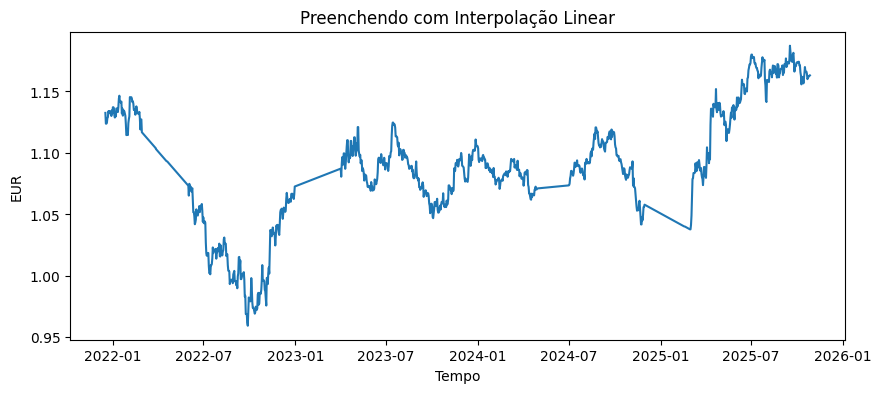

In [12]:
# TÉCNICA 2: Imputação Baseada em Séries Temporais (Pandas Interpolate)
# Interpolação Linear (usa os vizinhos para traçar uma linha reta)
ts_linear = ts_missing_block.interpolate(method='linear')

plotar(ts_linear, 'Preenchendo com Interpolação Linear')

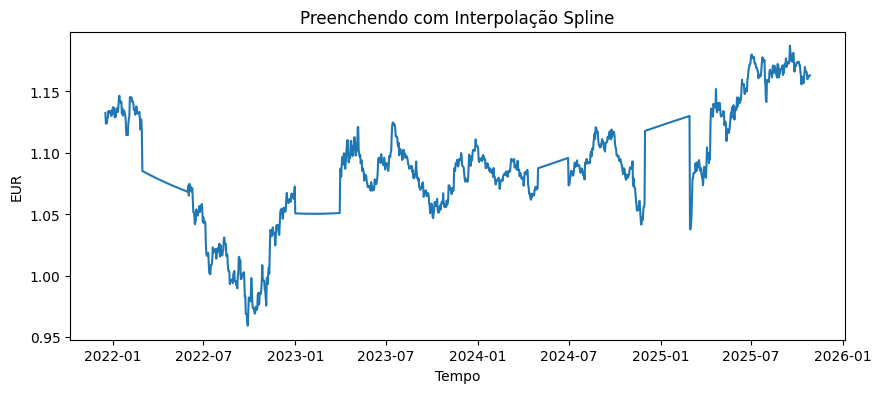

In [13]:
# Interpolação Spline (usa funções polinomiais de grau 3 para suavizar)
ts_spline = ts_missing_block.interpolate(method='spline', order=3)

plotar(ts_spline, 'Preenchendo com Interpolação Spline')

In [14]:
# Comparação dos dados estimados com aqueles eliminados, utilizando quatro métricas diferentes:

from sklearn.metrics import mean_squared_error, mean_absolute_error

# Valores originais que foram removidos
ground_truth = ts.loc[indices_removidos]

## Seleção da melhor estimação:
# Lista de todas as séries imputadas para iteração
series_imputadas = {
    "Média (Baseline)": ts_media,
    "LOCF (Last Observation)": ts_locf,
    "Interpolação Linear": ts_linear,
    "Interpolação Spline (Ordem 3)": ts_spline,
}

resultados = {}

for nome, ts_imputada in series_imputadas.items():
    # 1. Extrair Apenas os Valores Imputados (os que preenchem os NaNs originais)
    # Valores estimados (imputados) nos índices faltantes
    valores_estimados = ts_imputada.loc[indices_removidos]
    
    # 2. Calcular as Métricas de Erro (comparando estimado vs. verdadeiro)
    # MSE: Erro Quadrático Médio
    mse = mean_squared_error(ground_truth, valores_estimados)
    
    # RMSE: Raiz do Erro Quadrático Médio
    rmse = np.sqrt(mse)
    
    # MAE: Erro Médio Absoluto
    mae = mean_absolute_error(ground_truth, valores_estimados)
    
    # 3. Armazenar resultados
    resultados[nome] = {'RMSE': rmse, 'MAE': mae}


## Selecionando a melhor técnica:

# Cria um DataFrame para facilitar a visualização e comparação final
df_resultados = pd.DataFrame(resultados).T 

# Seleciona a melhor técnica baseada no RMSE (o menor valor é o melhor)
melhor_tecnica_rmse = df_resultados['RMSE'].idxmin()

print("\nMÉTRICAS DE ERRO:")
print(df_resultados.sort_values(by='RMSE'))
print(f"\nA melhor técnica (menor RMSE) de preenchimento é: {melhor_tecnica_rmse}")


MÉTRICAS DE ERRO:
                                   RMSE       MAE
Interpolação Linear            0.006998  0.002682
LOCF (Last Observation)        0.012259  0.004363
Média (Baseline)               0.014562  0.005679
Interpolação Spline (Ordem 3)  0.022537  0.008259

A melhor técnica (menor RMSE) de preenchimento é: Interpolação Linear


In [15]:
df_resultados

,RMSE,MAE
Média (Baseline),0.014562,0.005679
LOCF (Last Observation),0.012259,0.004363
Interpolação Linear,0.006998,0.002682
Interpolação Spline (Ordem 3),0.022537,0.008259


4. Aplique os três métodos de suavização de séries: SES: volatilidade, SEH : PIB americano, Holt winter: commodities.

In [27]:
from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt

resultados_suavizacao = {}

# 1. SES (Single Exponential Smoothing) para Volatilidade
fit1 = SimpleExpSmoothing(ts, initialization_method="estimated").fit(
    smoothing_level=0.1, optimized=False
)
resultados_suavizacao['SES'] = fit1.fittedvalues


c:\Users\Beatriz\Documents\UFPB\P7\Econometria 2\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


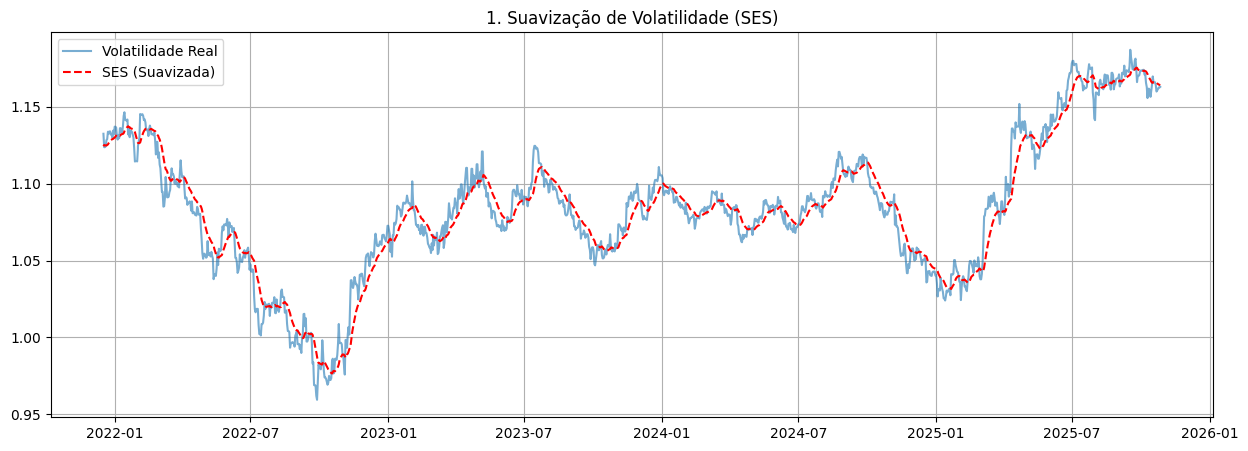

In [28]:
# Plot 1: SES na Volatilidade
plt.figure(figsize=(15, 5))
plt.plot(ts, label='Volatilidade Real', alpha=0.6)
plt.plot(resultados_suavizacao['SES'], label='SES (Suavizada)', color='red', linestyle='--')
plt.title('1. Suavização de Volatilidade (SES)')
plt.legend()
plt.grid(True)
plt.show()

In [43]:
# Plot 2: SEH no PIB Americano

file_path = 'GDP-USA-95-25.csv'
serie_pib = pd.read_csv(file_path, parse_dates=True, index_col=0)
serie_pib

,GDP
observation_date,
1995-04-01,7580.997
1995-07-01,7683.125
1995-10-01,7772.586
1996-01-01,7868.468
1996-04-01,8032.840
...,...
2024-04-01,29147.044
2024-07-01,29511.664
2024-10-01,29825.182


Parâmetro Alpha (Nível): 0.8846
Parâmetro Beta (Tendência): 0.0881


c:\Users\Beatriz\Documents\UFPB\P7\Econometria 2\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


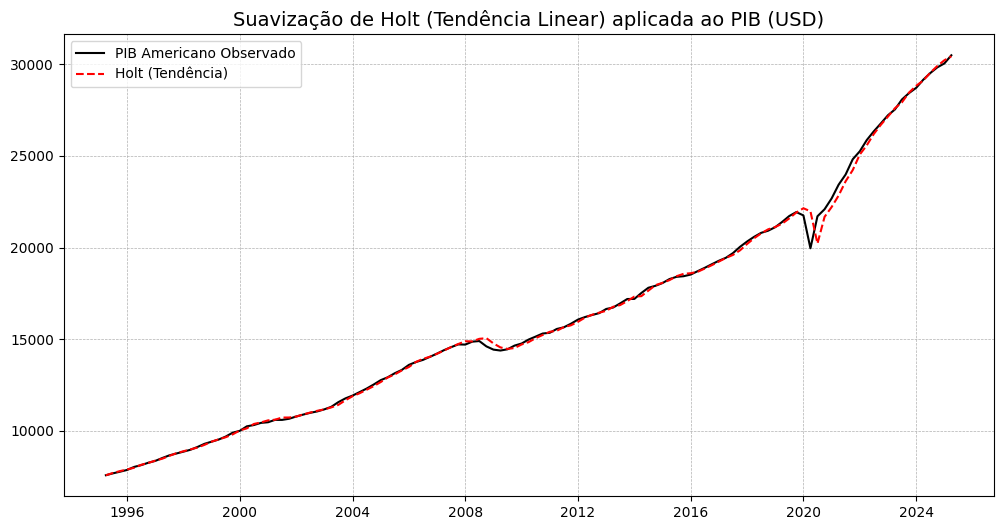

In [50]:
# Para PIB, 'mul' (multiplicativa) costuma ser bom se o crescimento for exponencial, mas 'add' (aditiva) é mais robusto inicialmente.
holt_model = ExponentialSmoothing(serie_pib, trend='add', seasonal=None, initialization_method="estimated")

holt_fit = holt_model.fit(optimized=True)
df_pib_holt = holt_fit.fittedvalues

print(f"Parâmetro Alpha (Nível): {holt_fit.params['smoothing_level']:.4f}")
print(f"Parâmetro Beta (Tendência): {holt_fit.params['smoothing_trend']:.4f}")

# Plotagem Holt
plt.figure(figsize=(12, 6))
plt.plot(serie_pib, label='PIB Americano Observado', color='black')
plt.plot(df_pib_holt, label='Holt (Tendência)', color='red', linestyle='--')
plt.title('Suavização de Holt (Tendência Linear) aplicada ao PIB (USD)', fontsize=14)
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

In [44]:
# Plot 3: Holt-Winters no Preço (Sazonalidade)
file_path = 'sugar.csv'

df = pd.read_csv(file_path, dtype=str)

try:
    # Lendo tudo como string primeiro para evitar que o Pandas confunda pontos de data com milhar
    df = pd.read_csv(file_path, dtype=str)

    # 1. TRATAMENTO DA DATA
    # Vamos limpar a coluna Data para garantir que ela esteja no formato certo
    # O dayfirst=True ajuda o Pandas a entender que o primeiro número é o dia (padrão BR)
    df['Data'] = pd.to_datetime(df['Data'], dayfirst=True, errors='coerce')

    # Removemos linhas onde a data não pôde ser lida (NaT)
    df = df.dropna(subset=['Data'])

    # Definindo o índice temporal
    df.set_index('Data', inplace=True)
    df.sort_index(inplace=True)

    # 2. TRATAMENTO DO PREÇO ('Último')
    # Função para limpar números brasileiros:
    # Remove o ponto de milhar (.) e troca a vírgula decimal (,) por ponto (.)
    def limpar_numero(valor):
        if isinstance(valor, str):
            valor = valor.replace('.', '') # Remove ponto de milhar
            valor = valor.replace(',', '.') # Troca vírgula por ponto
        return float(valor)

    # Aplicando a limpeza na coluna de preço
    serie_diaria = df['Último'].apply(limpar_numero)

    # 3. AGREGAÇÃO MENSAL
    # Reamostrando para média mensal para suavizar ruído diário
    serie_sugar = serie_diaria.resample('ME').mean()

    print("Dados carregados e tratados com sucesso!")
    print(f"Amostra dos dados processados:\n{serie_sugar.head()}")

except Exception as e:
    print(f"Erro persistente: {e}")
    # Dados Dummy de emergência
    dates = pd.date_range(start='2020-01-01', periods=60, freq='ME')
    serie_sugar = pd.Series(15 + np.random.normal(0, 2, 60), index=dates)
    print("Usando dados simulados.")

Dados carregados e tratados com sucesso!
Amostra dos dados processados:
Data
2021-01-31    15.916316
2021-02-28    16.967500
2021-03-31    15.805652
2021-04-30    16.237619
2021-05-31    17.195500
Freq: ME, Name: Último, dtype: float64


In [45]:
# Sazonalidade de 12 meses (anual) do preço do açúcar:
hw_model = ExponentialSmoothing(
    serie_sugar,
    trend='add',
    seasonal='add',
    seasonal_periods=12,
    initialization_method="estimated"
)
hw_fit = hw_model.fit(optimized=True)
sugar_hw = hw_fit.fittedvalues

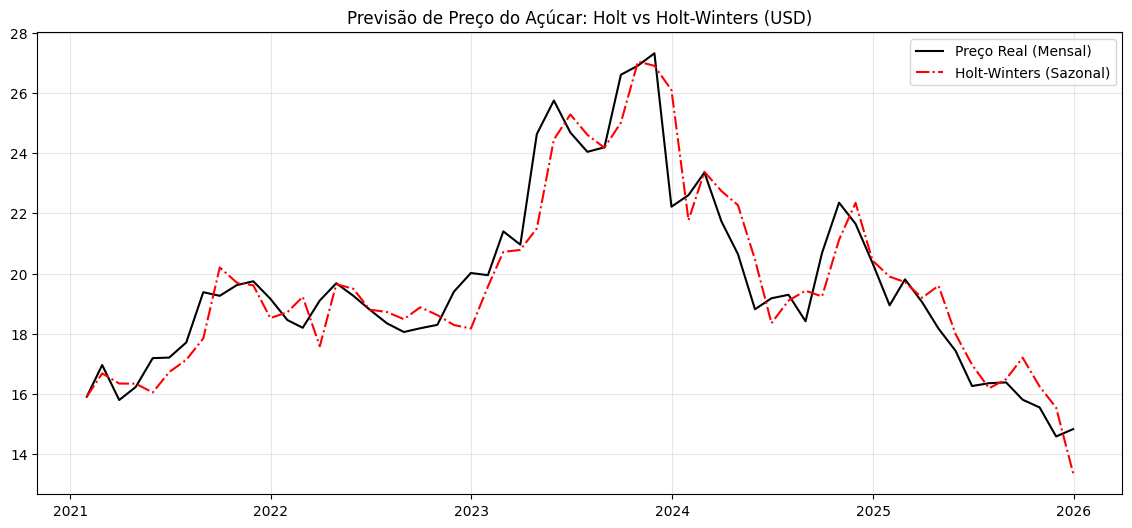

In [49]:
# Plot 2: Preço (Holt vs Holt-Winters)
plt.figure(figsize=(14, 6))
plt.plot(serie_sugar, label='Preço Real (Mensal)', color='black')
plt.plot(sugar_hw, label='Holt-Winters (Sazonal)', color='red', linestyle='-.')
plt.title('Previsão de Preço do Açúcar: Holt vs Holt-Winters (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()